## 1. Configuración

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models" / "tuned"
FIGURES_DIR = ROOT / "reports" / "figures"
REPORT_DIR = DATA_DIR / "08_reporting"

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_EPOCHS = 30
PATIENCE = 7
LR_CNN = 1e-4
LR_TRANSFORMER = 3e-5
SEED = 42

MODELS = [
    {"name": "efficientnet_b0",              "label": "EfficientNet-B0 (tuned)", "lr": LR_CNN},
    {"name": "resnet50",                     "label": "ResNet-50 (tuned)",      "lr": LR_CNN},
    {"name": "swin_tiny_patch4_window7_224", "label": "Swin Transformer (tuned)", "lr": LR_TRANSFORMER},
    {"name": "vit_tiny_patch16_224",         "label": "ViT tiny (tuned)",       "lr": LR_TRANSFORMER},
]

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")
print(f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE}")
print(f"LR CNN={LR_CNN} | LR Transformer={LR_TRANSFORMER}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128
Batch=32 | Max epochs=30 | Patience=7
LR CNN=0.0001 | LR Transformer=3e-05


## 2. DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"Train: {len(train_loader.dataset):,} chips | {len(train_loader):,} batches")
print(f"Val:   {len(val_loader.dataset):,} chips")
print(f"Test:  {len(test_loader.dataset):,} chips (notebook 05)")

Train: 81,938 chips | 2,561 batches
Val:   14,840 chips
Test:  14,806 chips (notebook 05)


## 3. Helpers — gráficos y exportación

In [3]:
def history_to_dataframe(summary: dict) -> pd.DataFrame:
    """Combina métricas train/val por epoch en un DataFrame."""
    train_df = pd.DataFrame(summary["history"]["train"]).add_prefix("train_")
    val_df = pd.DataFrame(summary["history"]["val"]).add_prefix("val_")
    if "train_epoch" in train_df.columns:
        train_df = train_df.rename(columns={"train_epoch": "epoch"})
    if "val_epoch" in val_df.columns:
        val_df = val_df.drop(columns=["val_epoch"])
    df = pd.concat([train_df, val_df], axis=1)
    df.insert(0, "model", summary.get("model_label", summary["model_name"]))
    df.insert(1, "timm_name", summary["model_name"])
    return df


def plot_training_curves(summary: dict, save_path: Path) -> None:
    history = summary["history"]
    label = summary.get("model_label", summary["model_name"])
    epochs = [r["epoch"] for r in history["train"]]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
    axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

    axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
    axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

    axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
    axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
    axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

    plt.suptitle(f"{label} — curvas de entrenamiento", y=1.02)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def format_epoch_line(epoch: int, max_ep: int, train_r: dict, val_r: dict, elapsed: float) -> str:
    return (
        f"Epoch {epoch:02d}/{max_ep} | "
        f"train loss {train_r['loss']:.4f} acc {train_r['accuracy']:.3f} | "
        f"val loss {val_r['loss']:.4f} acc {val_r['accuracy']:.3f} "
        f"F1 {val_r['macro_f1']:.3f} "
        f"(com recall {val_r['recall_com_garimpo']:.3f}) | "
        f"{elapsed:.0f}s"
    )

## 4. Entrenar los 4 modelos (tuned)


[1/4] Entrenando: EfficientNet-B0 (tuned) (efficientnet_b0) | LR=0.0001


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando efficientnet_b0 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.8790 acc 0.681 | val loss 0.6028 acc 0.651 F1 0.647 (com recall 0.836) | 225s
  → Mejor modelo guardado (macro F1 = 0.6466)


Epoch 02/30 | train loss 0.5341 acc 0.733 | val loss 0.5308 acc 0.726 F1 0.726 (com recall 0.791) | 130s
  → Mejor modelo guardado (macro F1 = 0.7263)


...

Epoch 06/30 | train loss 0.4539 acc 0.780 | val loss 0.5424 acc 0.729 F1 0.729 (com recall 0.814) | 140s


Epoch 07/30 | train loss 0.4445 acc 0.784 | val loss 0.5274 acc 0.736 F1 0.736 (com recall 0.812) | 129s


Epoch 08/30 | train loss 0.4378 acc 0.789 | val loss 0.5140 acc 0.753 F1 0.753 (com recall 0.789) | 129s


Epoch 09/30 | train loss 0.4293 acc 0.793 | val loss 0.5982 acc 0.747 F1 0.747 (com recall 0.820) | 129s


Epoch 10/30 | train loss 0.4204 acc 0.799 | val loss 0.5434 acc 0.731 F1 0.731 (com recall 0.842) | 130s
Early stopping en epoch 10 (sin mejora en 7 epochs)

Listo. Mejor epoch: 3 | val macro F1: 0.7566
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\tuned\efficientnet_b0_best.pt


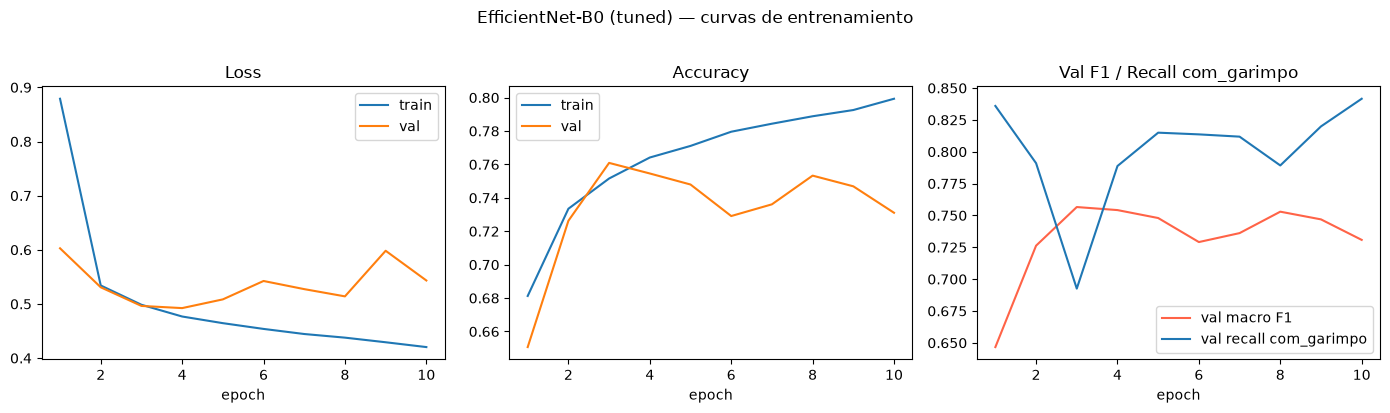


[2/4] Entrenando: ResNet-50 (tuned) (resnet50) | LR=0.0001


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando resnet50 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5475 acc 0.706 | val loss 0.5651 acc 0.710 F1 0.702 (com recall 0.603) | 139s
  → Mejor modelo guardado (macro F1 = 0.7021)


Epoch 02/30 | train loss 0.5075 acc 0.741 | val loss 0.5318 acc 0.725 F1 0.707 (com recall 0.528) | 110s
  → Mejor modelo guardado (macro F1 = 0.7074)


...

Epoch 24/30 | train loss 0.3911 acc 0.814 | val loss 0.5289 acc 0.766 F1 0.764 (com recall 0.744) | 124s


Epoch 25/30 | train loss 0.3862 acc 0.818 | val loss 0.5484 acc 0.738 F1 0.738 (com recall 0.828) | 125s


Epoch 26/30 | train loss 0.3830 acc 0.819 | val loss 0.8605 acc 0.665 F1 0.654 (com recall 0.934) | 126s


Epoch 27/30 | train loss 0.3801 acc 0.820 | val loss 0.7804 acc 0.707 F1 0.705 (com recall 0.868) | 125s


Epoch 28/30 | train loss 0.3787 acc 0.822 | val loss 0.5269 acc 0.768 F1 0.761 (com recall 0.658) | 126s
Early stopping en epoch 28 (sin mejora en 7 epochs)

Listo. Mejor epoch: 21 | val macro F1: 0.7670
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\tuned\resnet50_best.pt


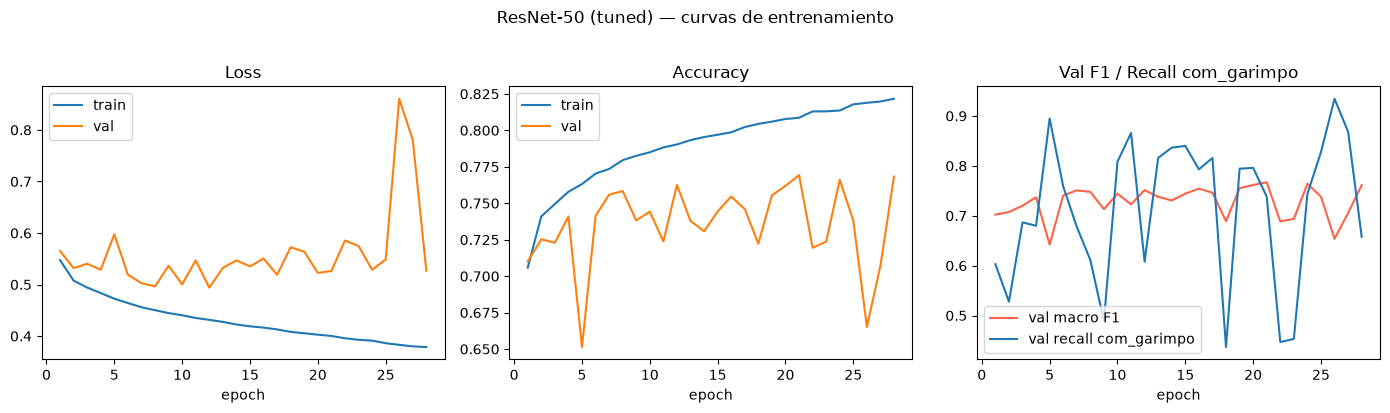


[3/4] Entrenando: Swin Transformer (tuned) (swin_tiny_patch4_window7_224) | LR=3e-05


c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)
c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an 

Entrenando swin_tiny_patch4_window7_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5137 acc 0.732 | val loss 0.5055 acc 0.738 F1 0.738 (com recall 0.816) | 219s
  → Mejor modelo guardado (macro F1 = 0.7383)


Epoch 02/30 | train loss 0.4724 acc 0.763 | val loss 0.4802 acc 0.755 F1 0.754 (com recall 0.758) | 215s
  → Mejor modelo guardado (macro F1 = 0.7536)


...

Epoch 05/30 | train loss 0.4295 acc 0.791 | val loss 0.5067 acc 0.750 F1 0.750 (com recall 0.815) | 253s


Epoch 06/30 | train loss 0.4222 acc 0.797 | val loss 0.5575 acc 0.705 F1 0.703 (com recall 0.864) | 244s


Epoch 07/30 | train loss 0.4149 acc 0.802 | val loss 0.5967 acc 0.706 F1 0.704 (com recall 0.858) | 235s


Epoch 08/30 | train loss 0.4085 acc 0.806 | val loss 0.6063 acc 0.722 F1 0.721 (com recall 0.857) | 239s


Epoch 09/30 | train loss 0.3993 acc 0.810 | val loss 0.6458 acc 0.732 F1 0.732 (com recall 0.851) | 240s
Early stopping en epoch 9 (sin mejora en 7 epochs)

Listo. Mejor epoch: 2 | val macro F1: 0.7536
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\tuned\swin_tiny_patch4_window7_224_best.pt


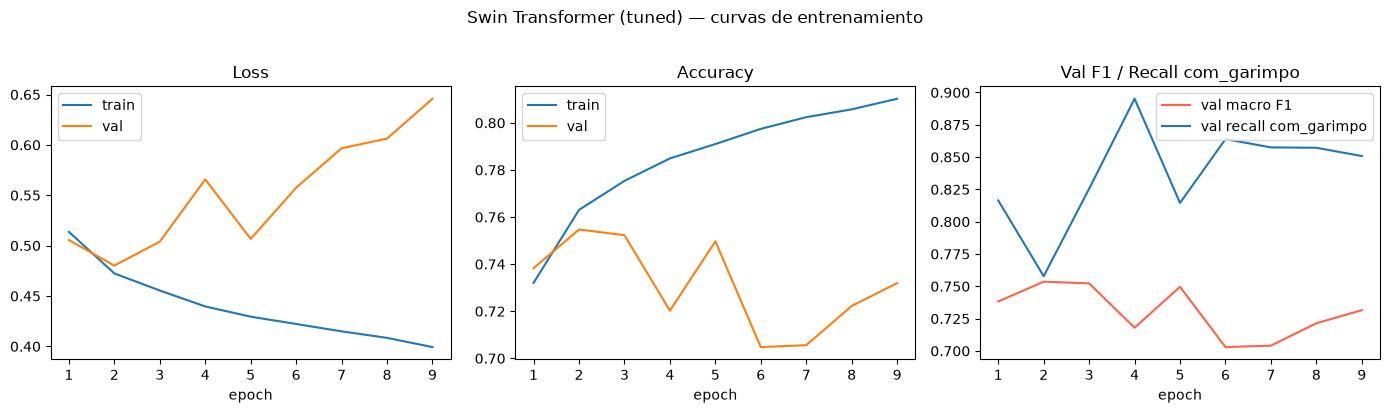


[4/4] Entrenando: ViT tiny (tuned) (vit_tiny_patch16_224) | LR=3e-05


C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\src\models\train.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Entrenando vit_tiny_patch16_224 en cuda (AMP activado)
Train: 81,938 | Val: 14,840


Epoch 01/30 | train loss 0.5329 acc 0.712 | val loss 0.5504 acc 0.693 F1 0.689 (com recall 0.887) | 163s
  → Mejor modelo guardado (macro F1 = 0.6890)


Epoch 02/30 | train loss 0.4989 acc 0.741 | val loss 0.5323 acc 0.708 F1 0.707 (com recall 0.847) | 161s
  → Mejor modelo guardado (macro F1 = 0.7065)


...

Epoch 08/30 | train loss 0.4475 acc 0.773 | val loss 0.5241 acc 0.730 F1 0.730 (com recall 0.849) | 95s


Epoch 09/30 | train loss 0.4417 acc 0.778 | val loss 0.5140 acc 0.738 F1 0.738 (com recall 0.801) | 93s


Epoch 10/30 | train loss 0.4362 acc 0.782 | val loss 0.4991 acc 0.746 F1 0.745 (com recall 0.764) | 95s


Epoch 11/30 | train loss 0.4329 acc 0.783 | val loss 0.5425 acc 0.717 F1 0.717 (com recall 0.846) | 93s


Epoch 12/30 | train loss 0.4276 acc 0.787 | val loss 0.5390 acc 0.732 F1 0.732 (com recall 0.812) | 93s
Early stopping en epoch 12 (sin mejora en 7 epochs)

Listo. Mejor epoch: 5 | val macro F1: 0.7529
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\tuned\vit_tiny_patch16_224_best.pt


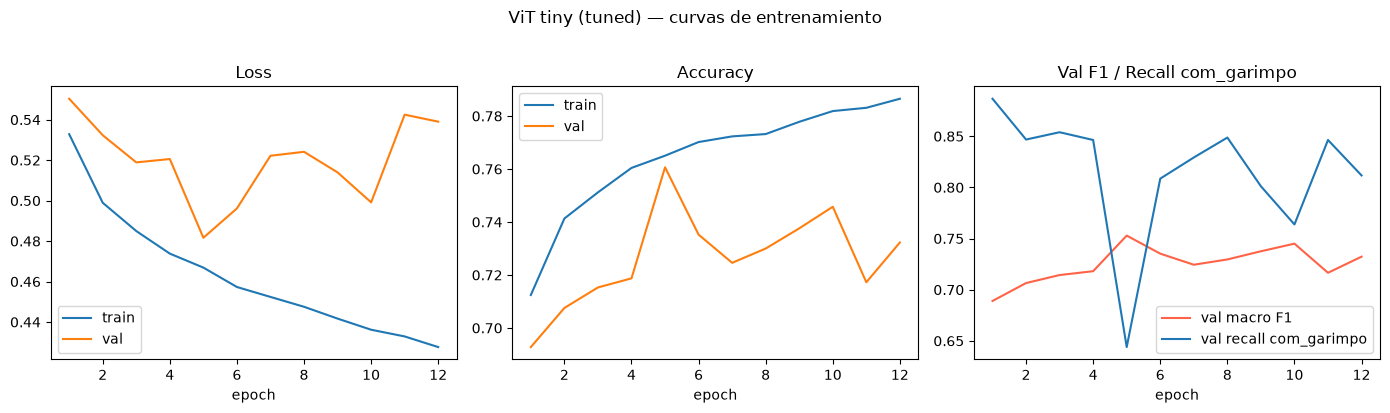


Entrenamiento (tuned) completado.


In [4]:
results = []
all_epochs_dfs = []
log_lines = [
    "TRAINING MODELS (TUNED) — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"PyTorch: {torch.__version__}",
    f"Batch={BATCH_SIZE} | Max epochs={MAX_EPOCHS} | Patience={PATIENCE}",
    f"LR CNN={LR_CNN} | LR Transformer={LR_TRANSFORMER}",
    f"Train chips: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}",
    "",
]

for i, model_cfg in enumerate(MODELS, start=1):
    name = model_cfg["name"]
    label = model_cfg["label"]
    lr = model_cfg["lr"]

    print("\n" + "=" * 60)
    print(f"[{i}/{len(MODELS)}] Entrenando: {label} ({name}) | LR={lr}")
    print("=" * 60)

    log_lines += ["=" * 60, f"MODELO: {label} ({name}) | LR={lr}", "=" * 60, ""]

    summary = train_model(
        model_name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        save_dir=MODELS_DIR,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        lr=lr,
    )
    summary["model_label"] = label

    # CSV por epoch de este modelo
    epoch_df = history_to_dataframe(summary)
    epoch_csv = REPORT_DIR / f"epochs_{name}_tuned.csv"
    epoch_df.to_csv(epoch_csv, index=False)
    all_epochs_dfs.append(epoch_df)

    # Líneas de texto por epoch
    for tr, va in zip(summary["history"]["train"], summary["history"]["val"]):
        log_lines.append(format_epoch_line(
            tr["epoch"], MAX_EPOCHS, tr, va, tr.get("time_s", 0)
        ))

    val_history = summary["history"]["val"]
    best_val = next(r for r in val_history if r["epoch"] == summary["best_epoch"])

    log_lines += [
        "",
        f"→ Mejor epoch: {summary['best_epoch']} | val macro F1: {summary['best_val_macro_f1']:.4f}",
        f"→ val accuracy: {best_val['accuracy']:.4f} | val recall com_garimpo: {best_val['recall_com_garimpo']:.4f}",
        f"→ Checkpoint: {summary['checkpoint']}",
        f"→ CSV epochs: {epoch_csv}",
        "",
    ]

    plot_training_curves(summary, FIGURES_DIR / f"{name}_tuned_training_curves.png")

    results.append({
        "model": label,
        "timm_name": name,
        "lr": lr,
        "best_epoch": summary["best_epoch"],
        "epochs_run": len(summary["history"]["train"]),
        "val_macro_f1": round(summary["best_val_macro_f1"], 4),
        "val_accuracy": round(best_val["accuracy"], 4),
        "val_recall_com_garimpo": round(best_val["recall_com_garimpo"], 4),
        "val_f1_com_garimpo": round(best_val["f1_com_garimpo"], 4),
        "val_f1_sem_garimpo": round(best_val["f1_sem_garimpo"], 4),
        "checkpoint": summary["checkpoint"],
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nEntrenamiento (tuned) completado.")

## 5. Guardar resumen (CSV + TXT)

In [5]:
results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
display(results_df)

# CSV resumen comparativo
summary_csv = REPORT_DIR / "training_results_summary_tuned.csv"
results_df.to_csv(summary_csv, index=False)

# CSV todas las epochs de los 4 modelos
all_epochs_csv = REPORT_DIR / "training_epochs_all_models_tuned.csv"
pd.concat(all_epochs_dfs, ignore_index=True).to_csv(all_epochs_csv, index=False)

# TXT legible
best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    "RESUMEN COMPARATIVO (validation, tuned)",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO (TUNED): {best['model']} | val macro F1 = {best['val_macro_f1']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / "training_results_tuned.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print(f"\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {all_epochs_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo (tuned): {best['model']} (val F1={best['val_macro_f1']})")

,model,timm_name,lr,best_epoch,epochs_run,val_macro_f1,val_accuracy,val_recall_com_garimpo,val_f1_com_garimpo,val_f1_sem_garimpo,checkpoint
1,ResNet-50 (tuned),resnet50,0.00010,21,28,0.7670,0.7693,0.7384,0.7436,0.7904,C:\Users\luisg\OneDrive\Documentos\Universidad...
0,EfficientNet-B0 (tuned),efficientnet_b0,0.00010,3,10,0.7566,0.7609,0.6925,0.7241,0.7891,C:\Users\luisg\OneDrive\Documentos\Universidad...
2,Swin Transformer (tuned),swin_tiny_patch4_window7_224,0.00003,2,9,0.7536,0.7547,0.7578,0.7368,0.7703,C:\Users\luisg\OneDrive\Documentos\Universidad...
3,ViT tiny (tuned),vit_tiny_patch16_224,0.00003,5,12,0.7529,0.7606,0.6439,0.7091,0.7967,C:\Users\luisg\OneDrive\Documentos\Universidad...



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results_summary_tuned.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_epochs_all_models_tuned.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\training_results_tuned.txt

Mejor modelo (tuned): ResNet-50 (tuned) (val F1=0.767)


## 6. Comparación rápida: original vs. tuned

In [6]:
original_csv = REPORT_DIR / "training_results_summary.csv"

if original_csv.exists():
    orig_df = pd.read_csv(original_csv)[["timm_name", "val_macro_f1", "val_accuracy"]]
    orig_df = orig_df.rename(columns={"val_macro_f1": "val_macro_f1_original",
                                       "val_accuracy": "val_accuracy_original"})

    tuned_df = results_df[["timm_name", "val_macro_f1", "val_accuracy"]].rename(
        columns={"val_macro_f1": "val_macro_f1_tuned", "val_accuracy": "val_accuracy_tuned"}
    )

    compare = orig_df.merge(tuned_df, on="timm_name", how="outer")
    compare["f1_gain_tuned_minus_original"] = (
        compare["val_macro_f1_tuned"] - compare["val_macro_f1_original"]
    ).round(4)
    display(compare.sort_values("f1_gain_tuned_minus_original", ascending=False))

    compare_csv = REPORT_DIR / "original_vs_tuned_comparison.csv"
    compare.to_csv(compare_csv, index=False)
    print(f"\nGuardado: {compare_csv}")
else:
    print("No se encontró training_results_summary.csv (corrida original de 04_training_models.ipynb).")

,timm_name,val_macro_f1_original,val_accuracy_original,val_macro_f1_tuned,val_accuracy_tuned,f1_gain_tuned_minus_original
3,vit_tiny_patch16_224,0.7231,0.7280,0.7529,0.7606,0.0298
2,swin_tiny_patch4_window7_224,0.7456,0.7456,0.7536,0.7547,0.0080
0,efficientnet_b0,0.7489,0.7491,0.7566,0.7609,0.0077
1,resnet50,0.7619,0.7627,0.7670,0.7693,0.0051



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\original_vs_tuned_comparison.csv


## 7. Próximo paso

Evaluar estos checkpoints (`data/06_models/tuned/`) en **test** con `05_evaluation.ipynb` — ya está preparado para buscar `.pt` también dentro de subcarpetas.